In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

In [2]:
with open("Datasets/GSE42568_series_matrix.txt", "r") as f:
    for i, line in enumerate(f):
        if i == 46:
            tissue_line = line.strip()
            break

tissue_values = tissue_line.split("\t")[1:]
tissue_values = [v.replace('"', '').replace('tissue: ', '').strip()
                 for v in tissue_values]

print("Unique types:", set(tissue_values))
print("Total samples:", len(tissue_values))

Unique types: {'normal breast', 'breast cancer'}
Total samples: 121


In [3]:
gse42568 = pd.read_csv(
    "Datasets/GSE42568_series_matrix.txt",
    sep="\t",
    comment="!",
    index_col=0
)
gse42568 = gse42568.dropna(axis=1, how='all')

print("Expression shape (genes × samples):", gse42568.shape)

Expression shape (genes × samples): (54675, 121)


In [4]:
gse42568_T = gse42568.T

y = np.array([1 if 'cancer' in t.lower() else 0 for t in tissue_values])

print("Expression shape (samples × genes):", gse42568_T.shape)
print("Label distribution:", pd.Series(y).value_counts().to_dict())

Expression shape (samples × genes): (121, 54675)
Label distribution: {1: 104, 0: 17}


In [5]:
X = gse42568_T.values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train_raw.shape}\nTest size: {X_test_raw.shape}")

Train size: (96, 54675)
Test size: (25, 54675)


In [6]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

In [7]:
selector = SelectKBest(f_classif, k=100)
X_train_sel = selector.fit_transform(X_train_imp, y_train)
X_test_sel  = selector.transform(X_test_imp)

In [8]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    preds = model.predict(X_test_sel)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n── {name} ──")
    print(classification_report(y_test, preds, target_names=['Normal', 'Tumor']))

print("\nFinal accuracies:", results)


── Random Forest ──
              precision    recall  f1-score   support

      Normal       1.00      0.75      0.86         4
       Tumor       0.95      1.00      0.98        21

    accuracy                           0.96        25
   macro avg       0.98      0.88      0.92        25
weighted avg       0.96      0.96      0.96        25


── SVM ──
              precision    recall  f1-score   support

      Normal       1.00      0.50      0.67         4
       Tumor       0.91      1.00      0.95        21

    accuracy                           0.92        25
   macro avg       0.96      0.75      0.81        25
weighted avg       0.93      0.92      0.91        25


── Logistic Regression ──
              precision    recall  f1-score   support

      Normal       1.00      0.75      0.86         4
       Tumor       0.95      1.00      0.98        21

    accuracy                           0.96        25
   macro avg       0.98      0.88      0.92        25
weighted avg   

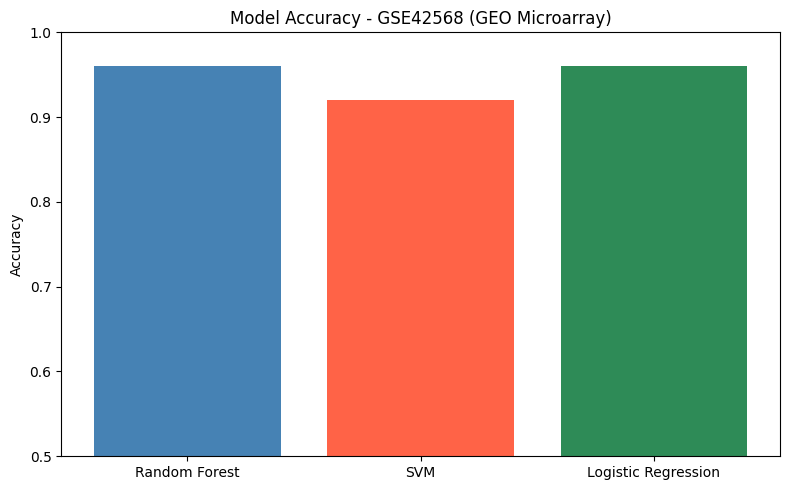

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(),
        color=['steelblue', 'tomato', 'seagreen'])
plt.title("Model Accuracy - GSE42568 (GEO Microarray)")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig('gse42568_accuracy.png', dpi=150)
plt.show()

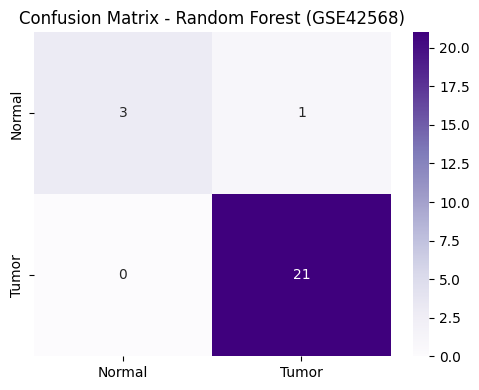

In [16]:
rf_preds = models["Random Forest"].predict(X_test_sel)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.title("Confusion Matrix - Random Forest (GSE42568)")
plt.tight_layout()
plt.savefig('gse42568_confusion.png', dpi=150)
plt.show()

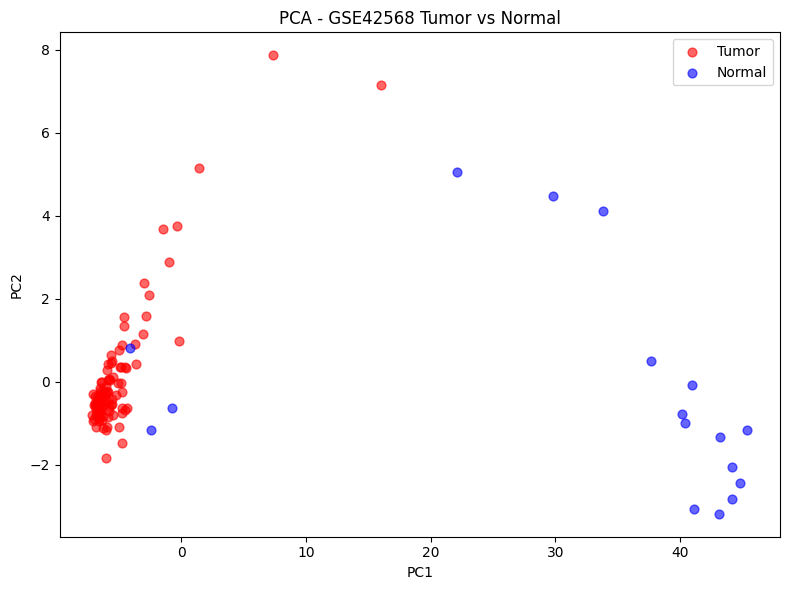

Accuracies: {'Random Forest': 0.96, 'SVM': 0.92, 'Logistic Regression': 0.96}


In [15]:
X_all_imp = imputer.transform(X)
X_all_sel = selector.transform(X_all_imp)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_sel)

plt.figure(figsize=(8, 6))
for label, color, name in [(1, 'red', 'Tumor'), (0, 'blue', 'Normal')]:
    idx = y == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                c=color, label=name, alpha=0.6, s=40)
plt.title("PCA - GSE42568 Tumor vs Normal")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig('gse42568_pca.png', dpi=150)
plt.show()

print("Accuracies:", results)